In [ ]:
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

MU = 30.0  # nonlinearity factor
X0 = 1.0  # initial position x(0)
V0 = 0.0  # initial velocity x'(0)

PERIOD_MARGIN = 1.15
ROUGH_PERIOD_FACTOR = 1.614
N_PERIODS_SETTLE = 4

N_WINDOWS_TARGET = 10  # initial equidistribution target: actual count may grow via MAX_WIDTH splitting
LAYERS = (1, 32, 32, 32, 32, 1)  # shared depth/width; input dim replaced by 2*mapping_size in the Fourier encoder
N_COLLOCATION_PER_WINDOW = 2000
COLLOCATION_SCALE_CAP = 3.0
ADAM_EPOCHS = 3000
ADAM_LR = 1e-3
GRAD_CLIP_NORM = 10.0
LBFGS_MAX_ITER = 2000
PRINT_EVERY = 500

# Adaptive collocation resampling (same values as the Standard PINN / SIREN v2)
RESAMPLE_EVERY = 500
RESAMPLE_CANDIDATE_MULT = 5
RESAMPLE_UNIFORM_FLOOR = 0.2

# Non-uniform window placement -- MIN/MAX match Stephen's Standard PINN exactly
COARSE_N_POINTS = 4000
MIN_WINDOW_WIDTH = 0.15
MAX_WINDOW_WIDTH = 3.0
MONITOR_VELOCITY_WEIGHT = 0.4
MONITOR_ACCEL_WEIGHT = 0.6

# Convergence retry
LOSS_CONVERGENCE_THRESHOLD = 1e-4
MAX_RETRIES_PER_WINDOW = 2

# Fourier-specific: joint sigma / mapping-size sweep
FOURIER_MAPPING_SIZE = 16
FOURIER_SIGMA = 5.0
SIGMA_CANDIDATES = [0.5, 1, 2, 5, 10, 20, 30]
MAPPING_SIZE_CANDIDATES = [12, 16, 32]
SIGMA_PROBE_EPOCHS = 800

Using device: cuda


In [ ]:
def van_der_pol_rhs(t, y, mu=MU):
    x, v = y
    return [v, mu * (1 - x ** 2) * v - x]

def estimate_vdp_period(mu, x0=X0, v0=V0, rough_factor=ROUGH_PERIOD_FACTOR, n_settle=N_PERIODS_SETTLE):
    rough_T = rough_factor * mu
    t_span = n_settle * max(rough_T, 5.0)

    def event_peak(t, y):
        return y[1]
    event_peak.direction = -1

    sol = solve_ivp(
        lambda t, y: van_der_pol_rhs(t, y, mu=mu),
        [0.0, t_span], [x0, v0],
        events=event_peak, rtol=1e-10, atol=1e-12, max_step=0.05,
    )
    peak_times = sol.t_events[0]
    if len(peak_times) < 3:
        print(f"[period detection] not enough peaks found, falling back to rough estimate {rough_T:.3f}")
        return rough_T
    return peak_times[-1] - peak_times[-2]


vdp_period = estimate_vdp_period(MU)
T_FINAL = float(PERIOD_MARGIN * vdp_period)
print(f"Detected VdP period at mu={MU}: {vdp_period:.4f}  ->  T_FINAL = {T_FINAL:.4f}")

Detected VdP period at mu=30.0: 50.5437  ->  T_FINAL = 58.1252


In [ ]:
class BasePINN(nn.Module):
    # Shared architecture skeleton: encode_input() + trunk_forward()

    def __init__(self):
        super().__init__()

    def encode_input(self, t):
        raise NotImplementedError

    def trunk_forward(self, encoded):
        raise NotImplementedError

    def forward(self, t):
        return self.trunk_forward(self.encode_input(t))

    @staticmethod
    def init_linear(linear):
        nn.init.xavier_normal_(linear.weight)
        nn.init.zeros_(linear.bias)

In [ ]:
class FourierFeaturePINN(BasePINN):
    """
    Random Fourier Feature PINN (Tancik et al.). encode_input() normalizes t
    into [-1, 1] over this window, then maps it through a fixed random
    frequency matrix B: gamma(t) = [cos(2*pi*B*t), sin(2*pi*B*t)].
    trunk_forward() is the same tanh MLP shape as the Standard PINN, with the
    input layer sized for 2*mapping_size instead of 1.
    """

    def __init__(self, t_start, window_size, layers=LAYERS,
                 mapping_size=FOURIER_MAPPING_SIZE, sigma=FOURIER_SIGMA, B=None):
        super().__init__()
        self.t_start = t_start
        self.window_size = window_size
        self.mapping_size = mapping_size
        self.sigma = sigma

        if B is None:
            B = torch.randn(1, mapping_size) * sigma
        else:
            B = B.clone().detach()
        self.register_buffer("B", B)

        fourier_layers = (2 * mapping_size,) + tuple(layers[1:])
        self.trunk = nn.ModuleList()
        for i in range(len(fourier_layers) - 1):
            linear = nn.Linear(fourier_layers[i], fourier_layers[i + 1])
            self.init_linear(linear)
            self.trunk.append(linear)
        self.activation = torch.tanh

    def encode_input(self, t):
        tau = t - self.t_start
        t_norm = (2.0 * tau / self.window_size) - 1.0
        proj = 2.0 * np.pi * (t_norm @ self.B)
        return torch.cat([torch.cos(proj), torch.sin(proj)], dim=-1)

    def trunk_forward(self, encoded):
        out = encoded
        for layer in self.trunk[:-1]:
            out = self.activation(layer(out))
        return self.trunk[-1](out)

In [ ]:
class WindowPINN(nn.Module):
    """
    Time-marching wrapper, wraps base architecture (FourierFeaturePinn) and enforces this window's initial condition exactly:
    x(t) = x0_local + v0_local * tau + tau^2 * base_model(t)
    """
    def __init__(self, base_model, t_start, window_size, x0_local, v0_local):
        super().__init__()
        self.base_model = base_model
        self.t_start = t_start
        self.window_size = window_size
        self.x0_local = x0_local
        self.v0_local = v0_local

    def forward(self, t):
        tau = t - self.t_start
        n_raw = self.base_model(t)
        return self.x0_local + self.v0_local * tau + (tau ** 2) * n_raw

In [ ]:
def physics_residual(model, t, mu=MU):
    x = model(t)
    x_t = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(x), create_graph=True, retain_graph=True)[0]
    x_tt = torch.autograd.grad(x_t, t, grad_outputs=torch.ones_like(x_t), create_graph=True, retain_graph=True)[0]
    return x_tt - mu * (1.0 - x ** 2) * x_t + x

def compute_loss(model, t_f):
    # only the physics residual; IC is hard-enforced, no loss_ic term
    f_pred = physics_residual(model, t_f)
    return torch.mean(f_pred ** 2)

def sample_collocation_points(t_start, t_end, n):
    t_f = np.random.uniform(low=t_start, high=t_end, size=(n, 1))
    t_f = torch.tensor(t_f, dtype=torch.get_default_dtype(), device=device)
    t_f.requires_grad_(True)
    return t_f

def evaluate_state(model, t_value):
    # (x, x') of a trained window model at a single time becomes the hard IC handed to the next window
    t_tensor = torch.tensor([[t_value]], dtype=torch.get_default_dtype(), device=device, requires_grad=True)
    x = model(t_tensor)
    x_t = torch.autograd.grad(x, t_tensor, grad_outputs=torch.ones_like(x))[0]
    return x.item(), x_t.item()

In [ ]:
def adaptive_collocation_points(model, t_start, t_end, n_points, n_candidates_mult=RESAMPLE_CANDIDATE_MULT, uniform_floor=RESAMPLE_UNIFORM_FLOOR):
    n_candidates = max(n_points * n_candidates_mult, n_points)
    t_candidates_np = np.random.uniform(t_start, t_end, size=(n_candidates, 1))
    t_candidates = torch.tensor(t_candidates_np, dtype=torch.get_default_dtype(), device=device)
    t_candidates.requires_grad_(True)
    residual = physics_residual(model, t_candidates)
    scores = (residual.detach() ** 2).cpu().numpy().flatten()
    scores += 1e-12
    probs = scores / scores.sum()
    n_weighted = int(round(n_points * (1.0 - uniform_floor)))
    n_uniform = n_points - n_weighted
    weighted_idx = np.random.choice(n_candidates, size=n_weighted, replace=False, p=probs)
    t_weighted_np = t_candidates_np[weighted_idx]
    t_uniform_np = np.random.uniform(t_start, t_end, size=(n_uniform, 1))
    t_new_np = np.vstack([t_weighted_np, t_uniform_np])
    t_new = torch.tensor(t_new_np, dtype=torch.get_default_dtype(), device=device)
    t_new.requires_grad_(True)
    return t_new

def compute_nonuniform_window_edges(n_windows, t_final=T_FINAL, mu=MU, x0=X0, v0=V0, coarse_n_points=COARSE_N_POINTS, min_width=MIN_WINDOW_WIDTH, max_width=MAX_WINDOW_WIDTH):
    t_coarse = np.linspace(0.0, t_final, coarse_n_points)
    sol = solve_ivp(lambda t, y: van_der_pol_rhs(t, y, mu=mu), [0.0, t_final], [x0, v0], t_eval=t_coarse, method="RK45", rtol=1e-9, atol=1e-9)
    x_c, v_c = sol.y[0], sol.y[1]
    accel = mu * (1 - x_c ** 2) * v_c - x_c
    vel_norm = np.abs(v_c) / (np.abs(v_c).max() + 1e-12)
    acc_norm = np.abs(accel) / (np.abs(accel).max() + 1e-12)
    monitor = MONITOR_VELOCITY_WEIGHT * vel_norm + MONITOR_ACCEL_WEIGHT * acc_norm
    cumulative = np.concatenate([[0.0], np.cumsum(0.5 * (monitor[1:] + monitor[:-1]) * np.diff(t_coarse))])
    total_measure = cumulative[-1]
    targets = np.linspace(0.0, total_measure, n_windows + 1)
    edges = np.interp(targets, cumulative, t_coarse)
    edges[0], edges[-1] = 0.0, t_final
    # forward pass: enforce MIN_WINDOW_WIDTH left to right
    for i in range(1, len(edges) - 1):
        if edges[i] - edges[i - 1] < min_width:
            edges[i] = edges[i - 1] + min_width
    edges = np.clip(edges, 0.0, t_final)
    edges[-1] = t_final
    # backward pass: re-enforce from the right so the last window can't collapse below the floor
    for i in range(len(edges) - 2, 0, -1):
        if edges[i + 1] - edges[i] < min_width:
            edges[i] = edges[i + 1] - min_width
    edges = np.clip(edges, 0.0, t_final)
    edges[0], edges[-1] = 0.0, t_final
    edges = np.unique(edges)
    new_edges = [edges[0]]
    for i in range(len(edges) - 1):
        a, b = edges[i], edges[i + 1]
        width = b - a
        n_sub = max(int(np.ceil(width / max_width)), 1)
        sub_edges = np.linspace(a, b, n_sub + 1)[1:]
        new_edges.extend(sub_edges.tolist())
    edges = np.unique(np.array(new_edges))
    return edges, t_coarse, monitor

In [ ]:
def run_adam_phase(model, t_start, t_end, n_points, adam_epochs, window_idx, tag="Adam"):
    t_f = sample_collocation_points(t_start, t_end, n_points)
    history = []
    optimizer = torch.optim.Adam(model.parameters(), lr=ADAM_LR)
    for epoch in range(adam_epochs):
        if epoch > 0 and epoch % RESAMPLE_EVERY == 0:
            t_f = adaptive_collocation_points(model, t_start, t_end, n_points)
        optimizer.zero_grad()
        loss = compute_loss(model, t_f)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()
        history.append(loss.item())
        if epoch % PRINT_EVERY == 0:
            print(f"[window {window_idx}] [{tag}]  epoch {epoch:5d} | loss {loss.item():.3e}")
    return history, t_f

def run_lbfgs_phase(model, t_f, max_iter, window_idx, tag="L-BFGS"):
    history = []
    optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), max_iter=max_iter, tolerance_grad=1e-9, tolerance_change=1e-12, history_size=50, line_search_fn="strong_wolfe")
    counter = {"n": 0}
    def closure():
        optimizer_lbfgs.zero_grad()
        loss = compute_loss(model, t_f)
        loss.backward()
        history.append(loss.item())
        counter["n"] += 1
        if counter["n"] % PRINT_EVERY == 0:
            print(f"[window {window_idx}] [{tag}] iter {counter['n']:5d} | loss {loss.item():.3e}")
        return loss

    optimizer_lbfgs.step(closure)
    return history

In [ ]:
def train_window(model, t_start, t_end, n_points, adam_epochs, window_idx=0):
    history, t_f = run_adam_phase(model, t_start, t_end, n_points, adam_epochs, window_idx, tag="Adam")
    t_f = adaptive_collocation_points(model, t_start, t_end, n_points)
    history += run_lbfgs_phase(model, t_f, LBFGS_MAX_ITER, window_idx, tag="L-BFGS")
    retries = 0
    while history[-1] > LOSS_CONVERGENCE_THRESHOLD and retries < MAX_RETRIES_PER_WINDOW:
        retries += 1
        print(f"[window {window_idx}] loss {history[-1]:.3e} > {LOSS_CONVERGENCE_THRESHOLD:.1e} threshold "
              f"-> retry {retries}/{MAX_RETRIES_PER_WINDOW}")
        t_f = adaptive_collocation_points(model, t_start, t_end, n_points)
        history += run_lbfgs_phase(model, t_f, LBFGS_MAX_ITER, window_idx, tag=f"L-BFGS-retry{retries}")

    return history

In [ ]:
window_edges, coarse_t, coarse_monitor = compute_nonuniform_window_edges(N_WINDOWS_TARGET)
window_widths = np.diff(window_edges)
n_windows_actual = len(window_widths)
mean_width = window_widths.mean()
print(f"Non-uniform window edges (t): {np.round(window_edges, 3)}")
print(f"Window widths: {np.round(window_widths, 3)}")
print(f"Actual window count after MAX_WIDTH splitting: {n_windows_actual} (target was {N_WINDOWS_TARGET})")

Non-uniform window edges (t): [ 0.     0.636  0.786  0.936  3.701  6.466  9.231 11.995 14.76  17.525
 20.29  23.055 25.82  25.97  26.12  28.871 31.623 34.375 37.127 39.879
 42.63  45.382 48.134 50.886 51.122 51.272 53.557 55.841 58.125]
Window widths: [0.636 0.15  0.15  2.765 2.765 2.765 2.765 2.765 2.765 2.765 2.765 2.765
 0.15  0.15  2.752 2.752 2.752 2.752 2.752 2.752 2.752 2.752 2.752 0.236
 0.15  2.284 2.284 2.284]
Actual window count after MAX_WIDTH splitting: 28 (target was 10)


In [ ]:
def quick_pinn_probe(sigma, mapping_size, t_f, t_start, window_size, adam_epochs=SIGMA_PROBE_EPOCHS):
    torch.manual_seed(SEED)
    base = FourierFeaturePINN(t_start, window_size, mapping_size=mapping_size, sigma=sigma).to(device)
    model_w = WindowPINN(base, t_start, window_size, X0, V0).to(device)
    opt = torch.optim.Adam(model_w.parameters(), lr=ADAM_LR)
    loss = None
    for _ in range(adam_epochs):
        opt.zero_grad()
        loss = compute_loss(model_w, t_f)
        loss.backward()
        opt.step()
    return loss.item()

print("\n - Joint sigma / mapping-size sweep (multiple representative windows) - ")
probe_indices = sorted(set([0, n_windows_actual // 2, n_windows_actual - 1]))
probe_windows = [(int(window_edges[i]), float(window_edges[i]), float(window_widths[i])) for i in probe_indices]
probe_t_fs = {
    i: sample_collocation_points(window_edges[i], window_edges[i + 1], N_COLLOCATION_PER_WINDOW)
    for i in probe_indices
}

combo_losses = {}
for mapping_size_candidate in MAPPING_SIZE_CANDIDATES:
    for sigma_candidate in SIGMA_CANDIDATES:
        window_losses = [
            quick_pinn_probe(sigma_candidate, mapping_size_candidate, probe_t_fs[i],
                              t_start=float(window_edges[i]), window_size=float(window_widths[i]))
            for i in probe_indices
        ]
        avg_loss = float(np.mean(window_losses))
        combo_losses[(sigma_candidate, mapping_size_candidate)] = avg_loss
        per_window_str = ", ".join(f"{l:.2e}" for l in window_losses)
        print(f"  sigma={sigma_candidate:>5} mapping_size={mapping_size_candidate:>3} "
              f"-> avg probe loss {avg_loss:.3e}  (per-window: {per_window_str})")

FOURIER_SIGMA, FOURIER_MAPPING_SIZE = min(combo_losses, key=combo_losses.get)
print(f"- Selected FOURIER_SIGMA = {FOURIER_SIGMA}, FOURIER_MAPPING_SIZE = {FOURIER_MAPPING_SIZE} -\n")

np.random.seed(SEED)
torch.manual_seed(SEED)
shared_B = (torch.randn(1, FOURIER_MAPPING_SIZE) * FOURIER_SIGMA).to(device)


 - Joint sigma / mapping-size sweep (multiple representative windows) - 
  sigma=  0.5 mapping_size= 12 -> avg probe loss 1.964e+00  (per-window: 1.11e-01, 4.79e+00, 9.88e-01)
  sigma=    1 mapping_size= 12 -> avg probe loss 3.401e+01  (per-window: 1.58e-01, 1.01e+02, 1.13e+00)
  sigma=    2 mapping_size= 12 -> avg probe loss 1.536e+02  (per-window: 8.27e-01, 3.28e+02, 1.32e+02)
  sigma=    5 mapping_size= 12 -> avg probe loss 1.606e+02  (per-window: 9.10e+01, 3.03e+02, 8.83e+01)
  sigma=   10 mapping_size= 12 -> avg probe loss 4.934e+03  (per-window: 1.83e+03, 9.55e+03, 3.42e+03)
  sigma=   20 mapping_size= 12 -> avg probe loss 6.814e+04  (per-window: 5.58e+04, 8.68e+04, 6.17e+04)
  sigma=   30 mapping_size= 12 -> avg probe loss 3.689e+05  (per-window: 2.80e+05, 4.92e+05, 3.34e+05)
  sigma=  0.5 mapping_size= 16 -> avg probe loss 8.407e-01  (per-window: 9.00e-02, 1.51e+00, 9.26e-01)
  sigma=    1 mapping_size= 16 -> avg probe loss 9.193e+00  (per-window: 3.08e-01, 2.37e+01, 3.55e+00)

In [ ]:
start_time = time.time()
models = []
full_history = []
x0_cur, v0_cur = X0, V0
prev_base_state = None

for w in range(n_windows_actual):
    t_start = float(window_edges[w])
    t_end = float(window_edges[w + 1])
    width = t_end - t_start
    # scale collocation points and Adam epochs by window width relative to the mean
    width_ratio = width / mean_width
    n_points_w = int(round(N_COLLOCATION_PER_WINDOW * np.clip(width_ratio, 1.0, COLLOCATION_SCALE_CAP)))
    adam_epochs_w = int(round(ADAM_EPOCHS * np.clip(width_ratio, 1.0, 2.0)))

    base = FourierFeaturePINN(t_start, width, mapping_size=FOURIER_MAPPING_SIZE,
                               sigma=FOURIER_SIGMA, B=shared_B).to(device)
    if prev_base_state is not None:
        base.load_state_dict(prev_base_state)  # warm start from previous window

    model_w = WindowPINN(base, t_start, width, x0_cur, v0_cur).to(device)
    hist = train_window(model_w, t_start, t_end, n_points_w, adam_epochs_w, window_idx=w)
    full_history.extend(hist)

    x0_cur, v0_cur = evaluate_state(model_w, t_end)
    models.append(model_w)
    prev_base_state = base.state_dict()

training_time = time.time() - start_time
print(f"Time-marching training complete in {training_time:.1f}s.")

[window 0] [Adam]  epoch     0 | loss 8.464e+01
[window 0] [Adam]  epoch   500 | loss 2.597e-01
[window 0] [Adam]  epoch  1000 | loss 2.493e-01
[window 0] [Adam]  epoch  1500 | loss 2.135e-01
[window 0] [Adam]  epoch  2000 | loss 3.025e-01
[window 0] [Adam]  epoch  2500 | loss 2.432e-01
[window 0] [L-BFGS] iter   500 | loss 4.575e-05
[window 0] [L-BFGS] iter  1000 | loss 3.433e-06
[window 0] [L-BFGS] iter  1500 | loss 3.431e-06
[window 0] [L-BFGS] iter  2000 | loss 3.428e-06
[window 0] [L-BFGS] iter  2500 | loss 3.425e-06
[window 1] [Adam]  epoch     0 | loss 1.693e+07
[window 1] [Adam]  epoch   500 | loss 6.287e+06
[window 1] [Adam]  epoch  1000 | loss 1.936e+06
[window 1] [Adam]  epoch  1500 | loss 1.393e+06
[window 1] [Adam]  epoch  2000 | loss 3.336e+05
[window 1] [Adam]  epoch  2500 | loss 2.085e+05
[window 1] [L-BFGS] iter   500 | loss 1.382e+04
[window 1] [L-BFGS] iter  1000 | loss 5.153e+03
[window 1] [L-BFGS] iter  1500 | loss 3.088e+03
[window 1] [L-BFGS] iter  2000 | loss 1.

In [ ]:
t_eval = np.linspace(0, T_FINAL, 2000)
sol = solve_ivp(van_der_pol_rhs, [0, T_FINAL], [X0, V0], t_eval=t_eval, method="RK45", rtol=1e-10, atol=1e-10)
x_reference = sol.y[0]
v_reference = sol.y[1]

x_pred = np.zeros_like(t_eval)
for w, model_w in enumerate(models):
    t_start = window_edges[w]
    t_end = window_edges[w + 1]
    mask = (t_eval >= t_start) & (t_eval <= t_end + 1e-9)
    if not np.any(mask):
        continue
    t_local = torch.tensor(t_eval[mask].reshape(-1, 1), dtype=torch.get_default_dtype(), device=device)
    with torch.no_grad():
        x_local = model_w(t_local).cpu().numpy().flatten()
    x_pred[mask] = x_local

In [ ]:
mse = np.mean((x_pred - x_reference) ** 2)
relative_l2_error = np.linalg.norm(x_pred - x_reference) / np.linalg.norm(x_reference)
final_training_loss = full_history[-1]
n_params = sum(p.numel() for p in models[0].parameters())

# Calculate additional metrics
mae = np.mean(np.abs(x_pred - x_reference))
max_error = np.max(np.abs(x_pred - x_reference))
rmse = np.sqrt(mse)

t_res_test = torch.tensor(
    np.random.uniform(0.0, T_FINAL, size=(2000, 1)),
    dtype=torch.get_default_dtype(), device=device,
)
residual_vals = []
for w, model_w in enumerate(models):
    t_start = window_edges[w]
    t_end = window_edges[w + 1]
    mask = (t_res_test.detach().cpu().numpy().flatten() >= t_start) & \
           (t_res_test.detach().cpu().numpy().flatten() <= t_end)
    if np.any(mask):
        t_sub = t_res_test[mask].clone().detach().requires_grad_(True)
        f_sub = physics_residual(model_w, t_sub)
        residual_vals.append(f_sub.detach().cpu().numpy())
mean_physics_residual = np.mean(np.concatenate(residual_vals) ** 2) if residual_vals else float("nan")

print(f"Selected sigma: {FOURIER_SIGMA}")
print(f"Selected mapping_size: {FOURIER_MAPPING_SIZE}")
print(f"MSE: {mse:.3e}")
print(f"RMSE: {rmse:.3e}")
print(f"Relative L2 error: {relative_l2_error:.3e}")
print(f"MAE: {mae:.3e}")
print(f"Max Error: {max_error:.3e}")
print(f"Final training loss: {final_training_loss:.3e}")
print(f"Mean physics residual (test points): {mean_physics_residual:.3e}")
print(f"Training time: {training_time:.1f}s")
print(f"Trainable parameters (per window model): {n_params}")
print(f"Windows: {n_windows_actual}")

Selected sigma: 0.5
Selected mapping_size: 32
MSE: 7.913e+00
RMSE: 2.813e+00
Relative L2 error: 1.669e+00
MAE: 2.490e+00
Max Error: 4.159e+00
Final training loss: 7.150e-06
Mean physics residual (test points): 6.290e+00
Training time: 2647.0s
Trainable parameters (per window model): 5281
Windows: 28


## Performance Metrics

- **Selected Fourier Sigma:** {FOURIER_SIGMA}
- **Selected Fourier Mapping Size:** {FOURIER_MAPPING_SIZE}
- **Mean Squared Error (MSE):** {mse:.3e}
- **Root Mean Squared Error (RMSE):** {rmse:.3e}
- **Mean Absolute Error (MAE):** {mae:.3e}
- **Max Absolute Error:** {max_error:.3e}
- **Relative L2 Error:** {relative_l2_error:.3e}
- **Final Training Loss:** {final_training_loss:.3e}
- **Mean Physics Residual (test points):** {mean_physics_residual:.3e}
- **Training Time:** {training_time:.1f} seconds
- **Trainable Parameters (per window model):** {n_params}
- **Number of Windows:** {n_windows_actual}

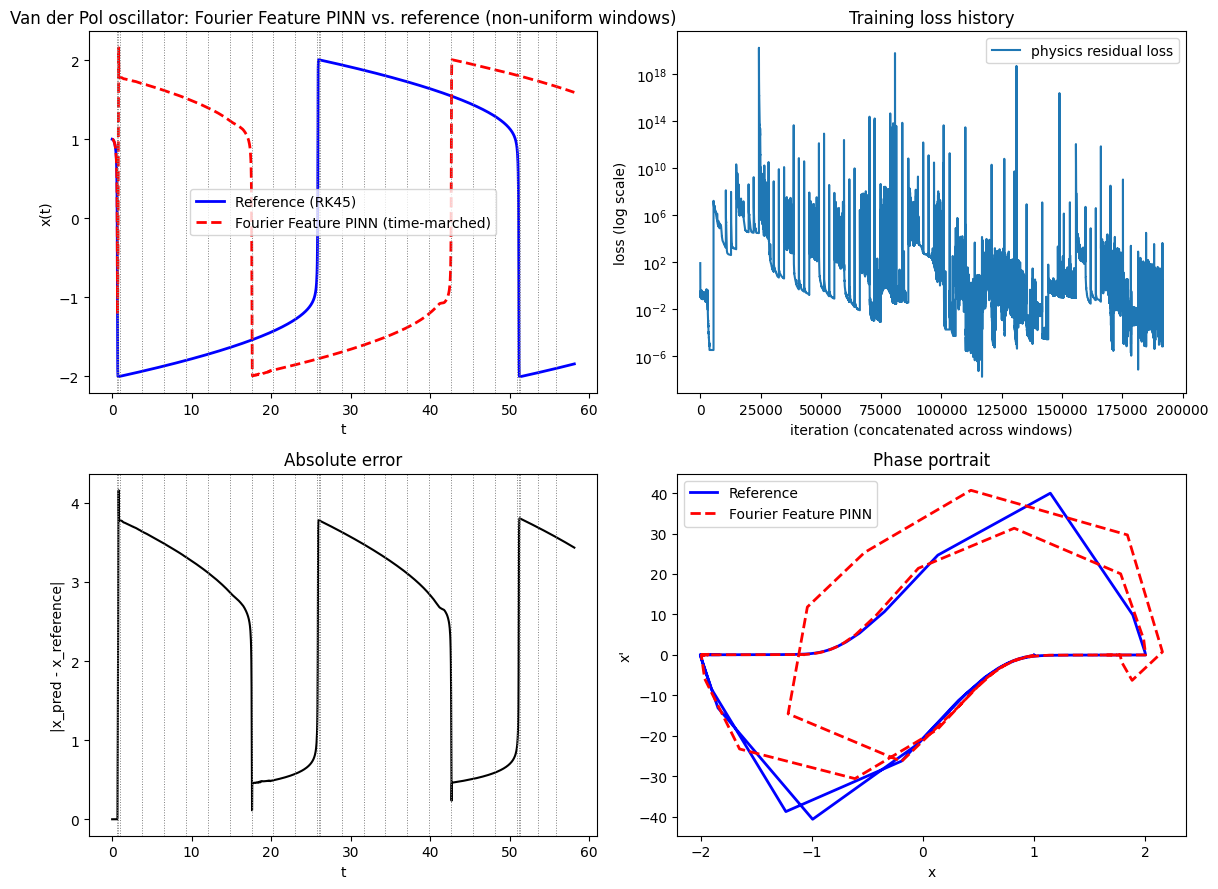

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].plot(t_eval, x_reference, "b-", linewidth=2, label="Reference (RK45)")
axes[0, 0].plot(t_eval, x_pred, "r--", linewidth=2, label="Fourier Feature PINN (time-marched)")
for edge in window_edges[1:-1]:
    axes[0, 0].axvline(edge, color="gray", linestyle=":", linewidth=0.7)
axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("x(t)")
axes[0, 0].set_title("Van der Pol oscillator: Fourier Feature PINN vs. reference (non-uniform windows)")
axes[0, 0].legend()

axes[0, 1].semilogy(full_history, label="physics residual loss")
axes[0, 1].set_xlabel("iteration (concatenated across windows)")
axes[0, 1].set_ylabel("loss (log scale)")
axes[0, 1].set_title("Training loss history")
axes[0, 1].legend()

axes[1, 0].plot(t_eval, np.abs(x_pred - x_reference), "k-")
for edge in window_edges[1:-1]:
    axes[1, 0].axvline(edge, color="gray", linestyle=":", linewidth=0.7)
axes[1, 0].set_xlabel("t")
axes[1, 0].set_ylabel("|x_pred - x_reference|")
axes[1, 0].set_title("Absolute error")

x_pred_dot = np.gradient(x_pred, t_eval)
axes[1, 1].plot(x_reference, v_reference, "b-", linewidth=2, label="Reference")
axes[1, 1].plot(x_pred, x_pred_dot, "r--", linewidth=2, label="Fourier Feature PINN")
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel("x'")
axes[1, 1].set_title("Phase portrait")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("fourier_pinn_adaptive_results.png", dpi=150)
plt.show()

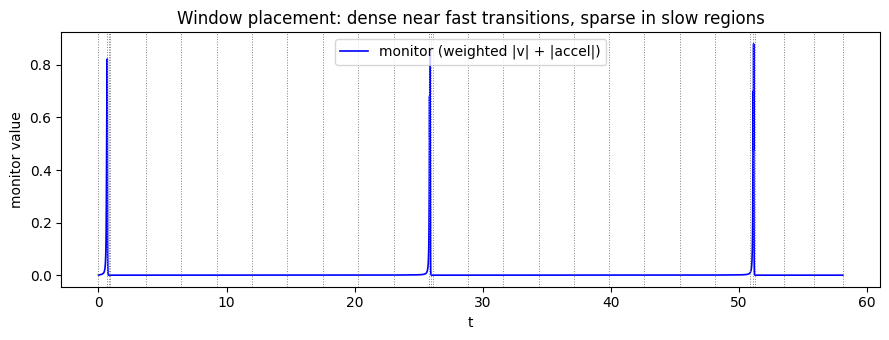

In [ ]:
fig2, ax2 = plt.subplots(figsize=(9, 3.5))
ax2.plot(coarse_t, coarse_monitor, "b-", linewidth=1.2, label="monitor (weighted |v| + |accel|)")
for edge in window_edges:
    ax2.axvline(edge, color="gray", linestyle=":", linewidth=0.7)
ax2.set_xlabel("t")
ax2.set_ylabel("monitor value")
ax2.set_title("Window placement: dense near fast transitions, sparse in slow regions")
ax2.legend()
plt.tight_layout()
plt.savefig("fourier_window_placement_diagnostic.png", dpi=150)
plt.show()